In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
for file_name in os.listdir('dice_scores'):
    data = pd.read_excel(f'dice_scores/{file_name}')
    print(f'{file_name}:')
    print(f'Mean Dice Score: {data[0].mean():.4f}')
    print(f'Percent > 0.8: {100 * (data[0] > 0.8).mean():.2f}%')
    print('\n')

FD032_DiceScore_df.xlsx:
Mean Dice Score: 0.4782
Percent > 0.8: 14.06%


FD030_DiceScore_df.xlsx:
Mean Dice Score: 0.7102
Percent > 0.8: 67.02%


FD_027_DiceScore_df.xlsx:
Mean Dice Score: 0.7316
Percent > 0.8: 49.90%


FD029_DiceScore_df.xlsx:
Mean Dice Score: 0.7198
Percent > 0.8: 50.79%


FD031_DiceScore_df.xlsx:
Mean Dice Score: 0.6249
Percent > 0.8: 45.32%




In [53]:
validation_per_subj_statistics = pd.read_csv('/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_performance_statistics/model-none-synthetic-real-ratio-0-2025-06-15T17-41-09/fold_1/validation_per_subj_statistics.csv')

In [54]:
dice_scores = validation_per_subj_statistics[validation_per_subj_statistics['epoch'] == validation_per_subj_statistics['epoch'].max()]['dice_coefficient']

In [57]:
print('Mean Dice Score (Validation Set):', dice_scores.mean())
print('Dice Scores > 0.8 (Validation Set):', str(100 * (dice_scores > 0.8).mean()) + '%')

Mean Dice Score (Validation Set): 0.7484443904860196
Dice Scores > 0.8 (Validation Set): 64.17624521072797%


In [32]:
((dice_scores > 0.8).sum() / len(dice_scores)) * 100

np.float64(64.17624521072797)

In [ ]:
# number of training samples total: 6303
# number of testing samples: 1566

# KFold cross-validation procedure: 5 folds,  6195 samples -> 5042 training samples / 1261 cross-validation samples

In [5]:
import torch
import segmentation_models_pytorch as smp

In [6]:
model = smp.Unet(
    encoder_name='efficientnet-b1',      # choose encoder, e.g. mobilenet_v2 or efficientnet-b7
    encoder_weights="imagenet",     # use `imagenet` pre-trained weights for encoder initialization
    in_channels=1,                  # model input channels (1 for gray-scale images, 3 for RGB, etc.)
    classes=1,        # model output channels (number of classes in your dataset)
    activation=None,
)

In [7]:
model_weights_path = '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/unet_performance_statistics/model-none-synthetic-real-ratio-0-2025-06-15T17-41-09/fold_1/model/best_model.pt'
model.load_state_dict(torch.load(model_weights_path, weights_only=True))

<All keys matched successfully>

In [20]:
model = model.to('cuda:1')

In [8]:
model.eval()

Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      1, 32, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          32, 32, kernel_size=(3, 3), stride=[1, 1], groups=32, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          32, 8, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          8, 32, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identit

In [9]:
import os
import sys

sys.path.append(os.path.dirname(os.getcwd()))

sys.path.insert(
    0,
    os.path.abspath(
        os.path.join(os.path.dirname(os.getcwd()), os.pardir)
    )
)


In [21]:
from torchvision import io

In [22]:
train_dir = '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/train-folders/train-200'
validation_dir = '/home/miguel/GI/1 - Segmentation/UNet-and-Synthesis-Results/validation'

In [23]:
os.listdir(train_dir)[0]

'case134_day0_slice_0043_stomach_mask.png'

In [12]:
sample_filename = os.listdir(validation_dir)[0]

In [24]:
sys.path.append('/home/miguel/GI/1 - Segmentation/Run-UNET')

In [32]:
from src.dataloader.dataloaders import MadisonDatasetLabeled
from src.evaluation.segmentation_metrics import dice_coefficient

In [26]:
val_dataset = MadisonDatasetLabeled(validation_dir, augment=False)

Number of images: 1566
Number of masks: 1566
Number of fake images: 0


In [27]:
val_iter = iter(val_dataset)

In [29]:
import torch.nn as nn

In [31]:
criterion(gt_mask, pred_mask)

TypeError: 'int' object is not callable

In [49]:
pred_mask[pred_mask > 0]

array([0.0462727 , 0.22340271, 0.23398408, ..., 1.1870811 , 0.8422098 ,
       0.39094543], dtype=float32)

In [40]:
dice_coefficient(mask.to('cuda:1'), pred)

0.8177419304847717

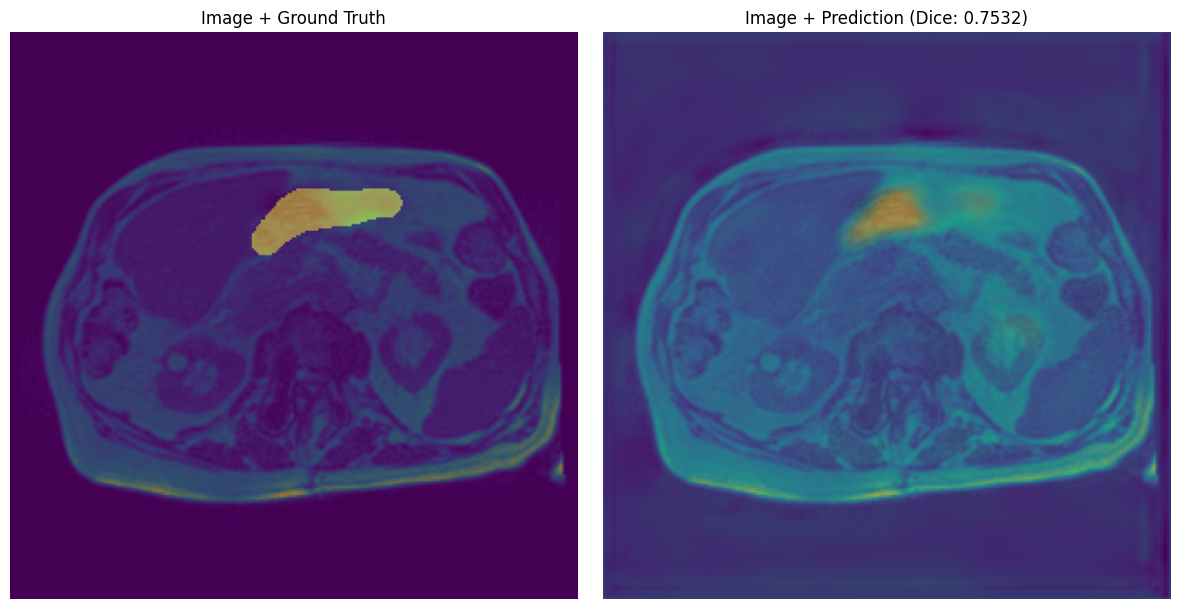

KeyboardInterrupt: 

In [51]:
for _ in range(50):
    image, mask, path = next(val_iter)
    image = image.to('cuda:1').unsqueeze(0)
    pred = model(image)

    dice = dice_coefficient(mask.to('cuda:1'), pred)

    # Convert to numpy
    img_np = image[0].cpu().detach().numpy()
    if img_np.ndim == 3:  # e.g. (3, H, W)
        img_np = img_np.transpose(1, 2, 0)
        img_cmap = None
    else:                # e.g. (1, H, W)
        img_np = img_np.squeeze()
        img_cmap = 'gray'

    gt_mask = mask[0].cpu().detach().numpy().squeeze()
    pred_mask = pred[0][0].cpu().detach().numpy()

    # Create side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Ground-truth overlay
    axes[0].imshow(img_np, cmap=img_cmap)
    axes[0].imshow(gt_mask, alpha=0.5)
    axes[0].set_title('Image + Ground Truth')
    axes[0].axis('off')

    # Predicted overlay
    axes[1].imshow(img_np, cmap=img_cmap)
    axes[1].imshow(pred_mask, alpha=0.5)
    axes[1].set_title(f'Image + Prediction (Dice: {dice:.4f})')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

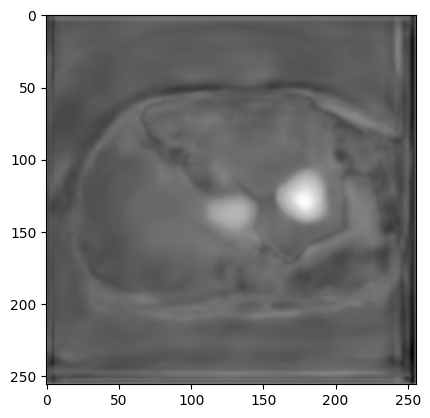

In [82]:
import torchvision

In [ ]:
sample_image = io.read_image(os.path.join(validation_dir, sample_filename), mode=torchvision.io.ImageReadMode.RGB)

In [84]:
sample_mask = io.read_image(os.path.join(validation_dir, sample_filename.replace('image.png', 'stomach_mask.png')), mode=torchvision.io.ImageReadMode.RGB)

In [68]:
model = model.to('cuda:1')

In [69]:
sample_image = sample_image.to('cuda:1')

In [71]:
sample_image.shape

torch.Size([1, 266, 266])

In [73]:
sample_image

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], device='cuda:1', dtype=torch.uint16)

In [79]:
from torchvision.transforms.functional import convert_image_dtype

In [80]:
convert_image_dtype(sample_image, torch.cuda.FloatTensor)

/home/miguel/anaconda3/envs/gsoc-2025-1/lib/python3.12/site-packages/torchvision/transforms/_functional_tensor.py:97: UserWarning: Defining your `__torch_function__` as a plain method is deprecated and will be an error in future, please define it as a classmethod. (Triggered internally at /pytorch/torch/csrc/utils/python_arg_parser.cpp:338.)
  if torch.tensor(0, dtype=dtype).is_floating_point():


TypeError: tensor(): argument 'dtype' must be torch.dtype, not torch.tensortype

In [74]:
model(sample_image)

RuntimeError: Input type (CUDAUInt16Type) and weight type (torch.cuda.FloatTensor) should be the same

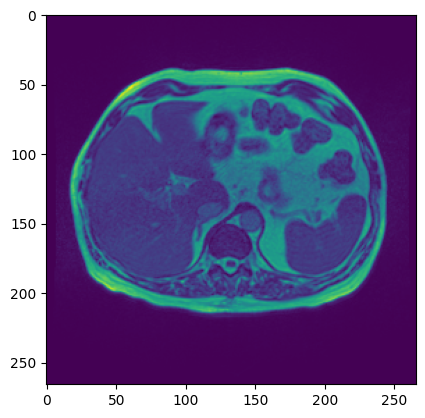

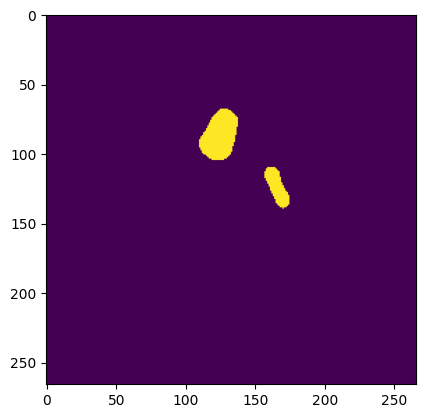

In [65]:
plt.imshow(sample_image[0])
plt.show()
plt.imshow(sample_mask[0])
plt.show()

In [ ]:
plt.imshow()

torch.Size([1, 266, 266])

In [ ]:
# Visualize predictions of the neural network